In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Session 9

## Torch DataSSets
- Fifa Dataset
<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

## Import Statements

In [10]:
###-----------------
### Import libraries
###-----------------
from pathlib import Path         # Import Path for file system path operations and management
import numpy as np               # Import NumPy for numerical computations and array operations
import pandas as pd              # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns            # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix, 
                             ConfusionMatrixDisplay, 
                             f1_score)                 # to calculate various metric

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix

In [11]:
# ###------------------
# ### Global Parameters
# ###------------------

# Directories
inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
fileName = 'fifa_2019.csv'

RANDOM_STATE = 24 
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results
torch.manual_seed(RANDOM_STATE)


EPOCHS = 100
ALPHA = 0.001
BATCH_SIZE = 32
TEST_SIZE  = 0.2 # Size of test data
TRAIN_SIZE = 454 * BATCH_SIZE 

# Parameters for plotting
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params)

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [12]:
18147*0.8/32

453.675

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [14]:
data_df = pd.read_csv(inpDir/fileName)
data_df.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [15]:
# Following columns appear to be relevant for our analysis
rel_cols = ["Position", 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
            'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
            'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
            'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
            'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
            'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
            'GKKicking', 'GKPositioning', 'GKReflexes']

In [16]:
goalkeeper = 'GK'
forward = ['ST', 'LW', 'RW', 'LF', 'RF', 'RS','LS', 'CF']
midfielder = ['CM','RCM','LCM', 'CDM','RDM','LDM', 'CAM', 'LAM', 'RAM', 'RM', 'LM']
defender = ['CB', 'RCB', 'LCB', 'LWB', 'RWB', 'LB', 'RB']

In [17]:
data_df = data_df[rel_cols]
data_df =data_df[data_df['Position'].notnull()]
data_df.head()

,Position,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,RF,95.0,70.0,90.0,86.0,97.0,93.0,94.0,87.0,96.0,...,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0
1,ST,94.0,89.0,81.0,87.0,88.0,81.0,76.0,77.0,94.0,...,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0
2,LW,87.0,62.0,84.0,84.0,96.0,88.0,87.0,78.0,95.0,...,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0
3,GK,13.0,21.0,50.0,13.0,18.0,21.0,19.0,51.0,42.0,...,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0
4,RCM,82.0,55.0,92.0,82.0,86.0,85.0,83.0,91.0,91.0,...,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0


In [18]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18147 entries, 0 to 18206
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Position         18147 non-null  object 
 1   Finishing        18147 non-null  float64
 2   HeadingAccuracy  18147 non-null  float64
 3   ShortPassing     18147 non-null  float64
 4   Volleys          18147 non-null  float64
 5   Dribbling        18147 non-null  float64
 6   Curve            18147 non-null  float64
 7   FKAccuracy       18147 non-null  float64
 8   LongPassing      18147 non-null  float64
 9   BallControl      18147 non-null  float64
 10  Acceleration     18147 non-null  float64
 11  SprintSpeed      18147 non-null  float64
 12  Agility          18147 non-null  float64
 13  Reactions        18147 non-null  float64
 14  Balance          18147 non-null  float64
 15  ShotPower        18147 non-null  float64
 16  Jumping          18147 non-null  float64
 17  Stamina          

In [19]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Finishing,18147.0,45.550229,19.527445,2.0,30.0,49.0,62.0,95.0
HeadingAccuracy,18147.0,52.300766,17.381753,4.0,44.0,56.0,64.0,94.0
ShortPassing,18147.0,58.695432,14.696075,7.0,54.0,62.0,68.0,93.0
Volleys,18147.0,42.912217,17.695900,4.0,30.0,44.0,57.0,90.0
Dribbling,18147.0,55.375158,18.912224,4.0,49.0,61.0,68.0,97.0
Curve,18147.0,47.176283,18.396009,6.0,34.0,48.0,62.0,94.0
FKAccuracy,18147.0,42.866038,17.480034,3.0,31.0,41.0,57.0,94.0
LongPassing,18147.0,52.721386,15.325211,9.0,43.0,56.0,64.0,93.0
BallControl,18147.0,58.374828,16.685643,5.0,54.0,63.0,69.0,96.0
Acceleration,18147.0,64.612829,14.930320,12.0,57.0,67.0,75.0,97.0


In [20]:
for col in data_df.columns:
    print (f'Col: {col} - {data_df[col].unique()}')

Col: Position - ['RF' 'ST' 'LW' 'GK' 'RCM' 'LF' 'RS' 'RCB' 'LCM' 'CB' 'LDM' 'CAM' 'CDM'
 'LS' 'LCB' 'RM' 'LAM' 'LM' 'LB' 'RDM' 'RW' 'CM' 'RB' 'RAM' 'CF' 'RWB'
 'LWB']
Col: Finishing - [95. 94. 87. 13. 82. 84. 72. 93. 60. 11. 91. 76. 42. 65. 90. 14. 67. 89.
 33. 88. 59. 83. 77. 79. 80. 55. 70. 86. 10. 92. 38. 15. 51. 19. 73. 56.
 64. 81. 75. 52. 40. 69. 46. 48. 45. 47. 66. 78. 63. 54. 12. 34. 57. 43.
 37. 20. 41. 85. 18. 25.  9. 71. 44. 27. 21. 74. 31. 68. 39. 62. 29. 61.
 32. 50. 16. 53.  8. 23. 58. 30. 49. 17. 36. 28. 35. 26.  6. 22. 24.  7.
  5.  2.  4.]
Col: HeadingAccuracy - [70. 89. 62. 21. 55. 61. 77. 91. 15. 85. 54. 92. 68. 84. 11. 13. 25. 83.
 59. 76. 56. 52. 48. 79. 87. 75. 10. 80. 81. 73. 86. 35. 74. 58. 72. 51.
 14. 82. 38. 50. 49. 60. 63. 19. 16. 46. 94. 69. 65. 12. 78. 90. 31. 41.
 43. 64. 42. 53. 17. 44. 45. 34. 67. 23. 57. 88. 71. 47. 40. 66. 36. 20.
 39. 93.  8. 18.  7. 37. 32. 24. 33.  9. 30. 22. 28. 27. 29. 26.  5.  6.
  4.]
Col: ShortPassing - [90. 81. 84. 50. 92. 89

In [21]:
data_df.isna().sum()

Position           0
Finishing          0
HeadingAccuracy    0
ShortPassing       0
Volleys            0
Dribbling          0
Curve              0
FKAccuracy         0
LongPassing        0
BallControl        0
Acceleration       0
SprintSpeed        0
Agility            0
Reactions          0
Balance            0
ShotPower          0
Jumping            0
Stamina            0
Strength           0
LongShots          0
Aggression         0
Interceptions      0
Positioning        0
Vision             0
Penalties          0
Composure          0
Marking            0
StandingTackle     0
SlidingTackle      0
GKDiving           0
GKHandling         0
GKKicking          0
GKPositioning      0
GKReflexes         0
dtype: int64

In [22]:
data_df.loc[data_df['Position'] == 'GK', 'Position'] = 0
data_df.loc[data_df['Position'].isin(defender), 'Position'] = 1
data_df.loc[data_df['Position'].isin(midfielder), 'Position'] = 2
data_df.loc[data_df['Position'].isin(forward), 'Position'] = 3

data_df['Position'] = pd.to_numeric(data_df['Position'], downcast='integer')

In [23]:
class_labels = {0: 'Goal Keeper', 
                1: 'Defender', 
                2: 'Mid-fielder', 
                3: 'Forward'}

In [26]:
train_df, test_df = train_test_split(data_df,
                                     stratify=data_df['Position'],
                                     train_size=TRAIN_SIZE,
                                     #test_size=TEST_SIZE,
                                     random_state=RANDOM_STATE)
train_df.shape, test_df.shape

((14528, 34), (3619, 34))

### Custom Dataset

In [ ]:
class GlobalScaler:
    _instance = None

    def __init__(self):
        if GlobalScaler._instance is not None:
            raise Exception ('GlobalScaler is Singleton Class')
        self.scaler = StandardScaler()

    @classmethod
    def get_instance(cls):
        if cls._instance is None:
            cls._instance = GlobalScaler()
        return cls._instance

In [ ]:
class FifaDS(Dataset):
    globalScaler =GlobalScaler.get_instance() # Protected variable

    def __init__(self, 
                 dataframe, 
                 device = device, 
                 is_train = True, 
                 label_col = None):
        self.df = dataframe
        self.device = device
        self.is_train= is_train
        self.scaler = self.globalScaler.scaler
        self.label_col = label_col

        self.labels = self.df[label_col].to_numpy()
        if self.is_train:
            X = self.df.drop(label_col, axis = 1)
            self.features = self.scaler.fit_transform(X)
        else:
            X = self.df.drop(label_col, axis = 1)
            self.features = self.scaler.transform(X)
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        feature = self.features[index]
        label = self.labels[index]
        return feature, label
    
        


In [18]:
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [19]:
type(X_train), type(X_test), type(y_train), type(y_test)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

## Converting to Datasets

In [20]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

I0000 00:00:1763118199.439530   34468 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4095 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [21]:
train_ds = train_ds.shuffle(buffer_size=X_train.shape[0]).batch(BATCH_SIZE)
test_ds = test_ds.shuffle(buffer_size=X_test.shape[0]).batch(BATCH_SIZE)

In [22]:
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [23]:
next(iter(train_ds))

2025-11-14 16:33:20.342805: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


(<tf.Tensor: shape=(32, 33), dtype=float64, numpy=
 array([[ 1.45736448,  1.19120541,  0.97380057, ..., -0.25648389,
         -0.37503159, -0.26239981],
        [-0.33529162,  0.84598612,  0.42924284, ..., -0.31708813,
         -0.08146885, -0.09529454],
        [-0.23285413,  0.21308409,  0.42924284, ..., -0.25648389,
         -0.25760649, -0.26239981],
        ...,
        [ 0.27933333,  0.32815719,  0.2250337 , ..., -0.49890085,
         -0.25760649, -0.03959278],
        [-0.79626033, -0.64996413, -0.25145431, ..., -0.25648389,
         -0.31631904, -0.59661035],
        [-0.07919789,  0.09801099,  0.56538227, ..., -0.19587965,
         -0.37503159, -0.42950508]], shape=(32, 33))>,
 <tf.Tensor: shape=(32,), dtype=int8, numpy=
 array([3, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 3, 3, 2, 3, 2,
        1, 2, 0, 2, 1, 2, 3, 2, 2, 2], dtype=int8)>)

In [24]:
for features, labels in train_ds.take(5):
    print (features.shape, labels.shape)

(32, 33) (32,)
(32, 33) (32,)
(32, 33) (32,)
(32, 33) (32,)
(32, 33) (32,)


2025-11-14 16:33:20.441173: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-11-14 16:33:20.443341: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Define model

In [25]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(33,)),
    tf.keras.layers.Dense(66),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dense(36),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dense(4)
])

In [26]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)
model.compile(optimizer= optimizer,
              loss=loss_fn, metrics= ['accuracy'])

In [27]:
history = model.fit(train_ds, 
                    validation_data=test_ds,
                    epochs=EPOCHS)

Epoch 1/100


2025-11-14 16:33:21.676144: I external/local_xla/xla/service/service.cc:163] XLA service 0x772494005690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-14 16:33:21.676177: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-11-14 16:33:21.693000: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-14 16:33:21.781871: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-11-14 16:33:21.799732: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-14 16:33:21.

129/566 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7145 - loss: 0.7013

I0000 00:00:1763118204.556159   34540 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


566/566 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8486 - loss: 0.3698 - val_accuracy: 0.9429 - val_loss: 0.1842
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8731 - loss: 0.3065 - val_accuracy: 0.9714 - val_loss: 0.1732
Epoch 3/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8765 - loss: 0.2985 - val_accuracy: 0.9714 - val_loss: 0.1688
Epoch 4/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8781 - loss: 0.2936 - val_accuracy: 0.9714 - val_loss: 0.1640
Epoch 5/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8802 - loss: 0.2898 - val_accuracy: 0.9714 - val_loss: 0.1637
Epoch 6/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8809 - loss: 0.2868 - val_accuracy: 0.9714 - val_loss: 0.1643
Epoch 7/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8822 - loss: 0.2843 - val_accuracy: 0.9714 - val_loss: 0.1647
Epoch 8/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8829 - loss: 0.2820 - val_accuracy: 0.9714

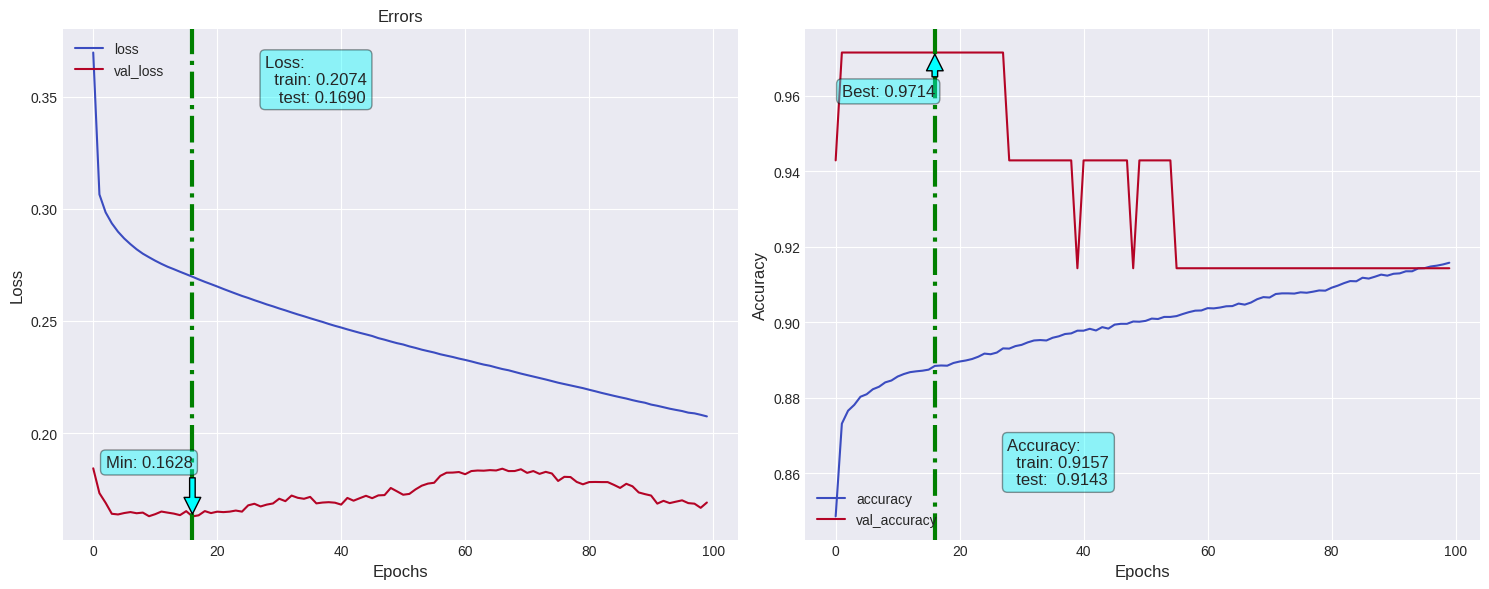

In [28]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [29]:
# model.evaluate(train_ds, verbose=2) # [0.2410917729139328, 0.9031480550765991]
# model.evaluate(test_ds, verbose=2) # [0.3128422796726227, 0.8727272748947144]


### Predictions

In [30]:
y_true, y_pred = [], []
for feat, lbls in train_ds:
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))

print (f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print (classification_report(y_true, y_pred))

2025-11-14 16:34:33.677502: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Accuracy: 0.9148
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2021
           1       0.93      0.96      0.95      5855
           2       0.91      0.86      0.89      6825
           3       0.85      0.89      0.87      3411

    accuracy                           0.91     18112
   macro avg       0.92      0.93      0.92     18112
weighted avg       0.92      0.91      0.91     18112



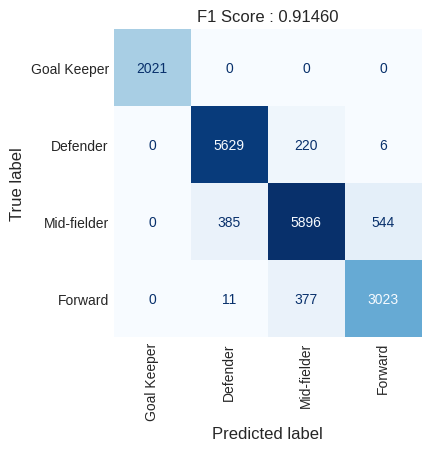

In [32]:
fn_plot_confusion_matrix(y_true, y_pred, class_labels)

In [ ]:
y_true, y_pred = [], []
for feat, lbls in tesfn_plot_confusion_matrix(y_true, y_pred, class_labels)t_ds:
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))

print (f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print (classification_report(y_true, y_pred))

Accuracy: 0.9143
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.92      1.00      0.96        11
           2       0.92      0.85      0.88        13
           3       0.86      0.86      0.86         7

    accuracy                           0.91        35
   macro avg       0.92      0.93      0.92        35
weighted avg       0.91      0.91      0.91        35



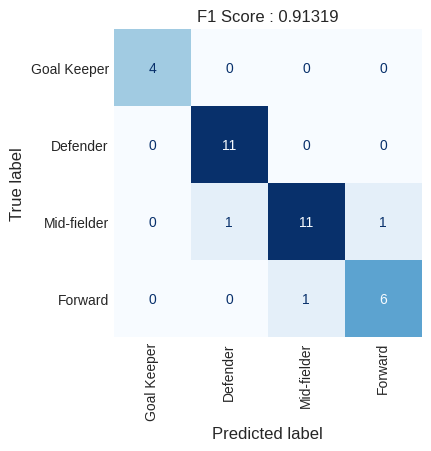

In [34]:
fn_plot_confusion_matrix(y_true, y_pred, class_labels)